# Matching experiment comparison

Observations from matching experiments are loaded from MongoDB, and node and relation matching quality is compared across models.

In [30]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pymongo import MongoClient

EXPERIMENTS = {
    "matching-gpt5-6-luna": "GPT-5.6 Luna",
    "glm-5-3-flash-matching": "GLM-5.3 Flash",
    "qwen3-8-flash-matching": "Qwen3-8 Flash",
    "gemini-3-5-flash-lite-matching": "Gemini 3.5 Flash Lite",
}
MODEL_COLORS = {
    "GPT-5.6 Luna": "#1f77b4",
    "GLM-5.3 Flash": "#ff7f0e",
    "Qwen3-8 Flash": "#9467bd",
    "Gemini 3.5 Flash Lite": "#d62728",
}
COLLECTION_NAME = "matching_eval"
MONGODB_URI = os.getenv(
    "MONGODB_URI",
    "mongodb://127.0.0.1:27017/llm_uml_evaluator?replicaSet=rs0",
)

plt.style.use("seaborn-v0_8-whitegrid")

## Data loading

The URI is read from the `MONGODB_URI` environment variable. JupyterLab is started with `uv run --env-file .env --group eval jupyter lab`.

In [31]:
client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5_000)
try:
    collection = client.get_default_database()[COLLECTION_NAME]
    documents = list(
        collection.find(
            {"experiment_name": {"$in": list(EXPERIMENTS)}},
            {
                "experiment_name": 1,
                "sample": 1,
                "mutation": 1,
                "nodes": 1,
                "relations": 1,
            },
        )
    )
finally:
    client.close()

loaded_experiments = {document["experiment_name"] for document in documents}
if missing := set(EXPERIMENTS).difference(loaded_experiments):
    raise ValueError(f"No observations found for: {sorted(missing)}")

pd.Series(
    (document["experiment_name"] for document in documents),
    name="experiment_name",
).value_counts().rename("observations")

experiment_name
matching-gpt5-6-luna              180
qwen3-8-flash-matching            180
gemini-3-5-flash-lite-matching    180
glm-5-3-flash-matching            180
Name: observations, dtype: int64

## Metric calculation

A match is a `(reference_uid, candidate_uid)` pair. The formulas are applied separately to node matches and relation matches:

- `TP`: a returned pair that is also expected;
- `FP`: a returned pair that is not expected;
- `FN`: an expected pair that was not returned.

```text
Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)
F1        = 2 × Precision × Recall / (Precision + Recall)
          = 2TP / (2TP + FP + FN)
```

The final, algebraically equivalent F1 formula is used. A metric with a zero denominator remains undefined (`NaN`) and is excluded from the mean.

In [32]:
df = pd.json_normalize(documents).rename(
    columns={
        "nodes.true_positive": "nodes_tp",
        "nodes.false_positive": "nodes_fp",
        "nodes.false_negative": "nodes_fn",
        "relations.true_positive": "relations_tp",
        "relations.false_positive": "relations_fp",
        "relations.false_negative": "relations_fn",
    }
)

required_columns = {
    "experiment_name",
    "sample",
    "mutation",
    "nodes_tp",
    "nodes_fp",
    "nodes_fn",
    "relations_tp",
    "relations_fp",
    "relations_fn",
}
if missing := required_columns.difference(df.columns):
    raise ValueError(f"Missing columns: {sorted(missing)}")

df["model"] = df["experiment_name"].map(EXPERIMENTS)

for component in ("nodes", "relations"):
    tp = df[f"{component}_tp"]
    fp = df[f"{component}_fp"]
    fn = df[f"{component}_fn"]
    precision_denominator = tp + fp
    recall_denominator = tp + fn
    f1_denominator = 2 * tp + fp + fn
    df[f"{component}_precision"] = tp / precision_denominator.where(
        precision_denominator.ne(0)
    )
    df[f"{component}_recall"] = tp / recall_denominator.where(
        recall_denominator.ne(0)
    )
    df[f"{component}_f1"] = 2 * tp / f1_denominator.where(
        f1_denominator.ne(0)
    )

df.head()

,_id,experiment_name,sample,mutation,nodes_tp,nodes_fp,nodes_fn,relations_tp,relations_fp,relations_fn,model,nodes_precision,nodes_recall,nodes_f1,relations_precision,relations_recall,relations_f1
0,matching-gpt5-6-luna_1_0_1,matching-gpt5-6-luna,1,0,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
1,matching-gpt5-6-luna_1_0_2,matching-gpt5-6-luna,1,0,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
2,matching-gpt5-6-luna_1_0_3,matching-gpt5-6-luna,1,0,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
3,matching-gpt5-6-luna_1_1_1,matching-gpt5-6-luna,1,1,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0
4,matching-gpt5-6-luna_1_1_2,matching-gpt5-6-luna,1,1,15,0,0,17,0,0,GPT-5.6 Luna,1.0,1.0,1.0,1.0,1.0,1.0


## Coverage check

The table shows the number of repetitions for each `model × sample × mutation` combination.

In [33]:
coverage = (
    df.groupby(["model", "sample", "mutation"], sort=False)
    .size()
    .unstack(fill_value=0)
)
display(coverage)
display(
    df.groupby(["model", "mutation"], sort=False)[
        ["nodes_f1", "relations_f1"]
    ].agg(["mean", "std", "count"]).round(3)
)

mutation                      0  1  2  3  4  5
model                 sample                  
GPT-5.6 Luna          1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3
Qwen3-8 Flash         1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3
Gemini 3.5 Flash Lite 1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3
GLM-5.3 Flash         1       3  3  3  3  3  3
                      2       3  3  3  3  3  3
                      3       3  3  3  3  3  3
                      4       3  3  3  3  3  3
                      5       3  3  3  3  3  3
                      6       3  3  3  3  3  3
                      7       3  3  3  3  3  3
                      8       3  3  3  3  3  3
                      9       3  3  3  3  3  3
                      10      3  3  3  3  3  3

nodes_f1              relations_f1             
                                   mean    std count         mean    std count
model                 mutation                                                
GPT-5.6 Luna          0           1.000  0.000    30        1.000  0.000    30
                      1           1.000  0.000    30        0.998  0.012    30
                      2           1.000  0.000    30        1.000  0.000    30
                      3           1.000  0.000    30        1.000  0.000    30
                      4           1.000  0.000    30        1.000  0.000    30
                      5           1.000  0.000    30        1.000  0.000    30
Qwen3-8 Flash         0           0.999  0.007    30        1.000  0.000    30
                      1           0.931  0.253    30        0.931  0.253    30
                      2           0.932  0.236    30        0.972  0.154    30
                      3           0.932  0.253    30        0.965  0.182    30
                      4           0.965  0.182    30        0.950  0.199    30
                      5           0.999  0.007    30        1.000  0.000    30
Gemini 3.5 Flash Lite 0           1.000  0.000    30        1.000  0.000    30
                      1           0.997  0.014    30        0.943  0.117    30
                      2           1.000  0.000    30        1.000  0.000    30
                      3           1.000  0.000    30        1.000  0.000    30
                      4           1.000  0.000    30        1.000  0.000    30
                      5           1.000  0.000    30        1.000  0.000    30
GLM-5.3 Flash         0           1.000  0.000    30        1.000  0.000    30
                      1           1.000  0.000    30        0.994  0.026    30
                      2           1.000  0.000    30        1.000  0.000    30
                      3           1.000  0.000    30        1.000  0.000    30
                      4           1.000  0.000    30        0.981  0.077    30
                      5           1.000  0.000    30        1.000  0.000    30

## Quality by mutation

Bars show mean F1 for each model; error bars span the minimum and maximum F1 observed across repetitions.

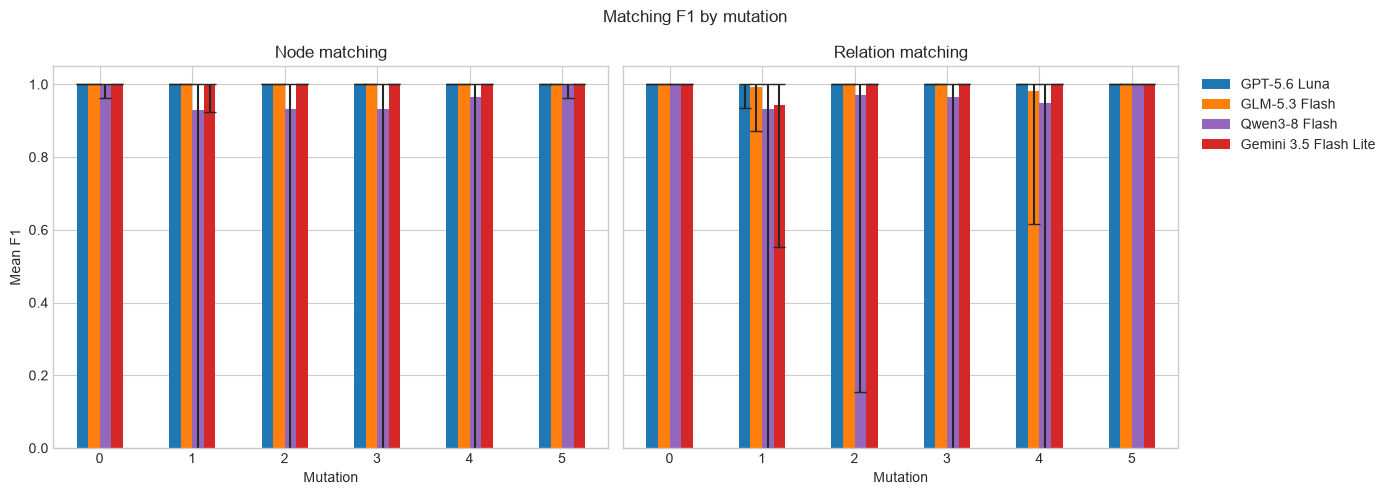

In [53]:
f1_by_mutation = df.groupby(["model", "mutation"], sort=False)[
    ["nodes_f1", "relations_f1"]
].agg(
    ["mean", "min", "max"]
)
f1_means = f1_by_mutation.xs("mean", axis=1, level=1)
f1_mins = f1_by_mutation.xs("min", axis=1, level=1)
f1_maxs = f1_by_mutation.xs("max", axis=1, level=1)
ylim = (0, 1.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, component, title in (
    (axes[0], "nodes", "Node matching"),
    (axes[1], "relations", "Relation matching"),
):
    means = (
        f1_means[f"{component}_f1"]
        .unstack("model")
        .reindex(columns=EXPERIMENTS.values())
    )
    minimums = (
        f1_mins[f"{component}_f1"]
        .unstack("model")
        .reindex(columns=EXPERIMENTS.values())
    )
    maximums = (
        f1_maxs[f"{component}_f1"]
        .unstack("model")
        .reindex(columns=EXPERIMENTS.values())
    )
    errors = {
        model: [
            (means[model] - minimums[model]).to_numpy(),
            (maximums[model] - means[model]).to_numpy(),
        ]
        for model in means
    }
    means.plot.bar(
        ax=ax,
        yerr=errors,
        capsize=4,
        rot=0,
        color=[MODEL_COLORS[model] for model in means],
    )
    ax.set(title=title, xlabel="Mutation", ylim=ylim)
axes[0].set_ylabel("Mean F1")
axes[0].get_legend().remove()
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Matching F1 by mutation")
fig.tight_layout()
plt.show()

## Error profile

Mean number of false (`FP`) and missed (`FN`) matches per observation.

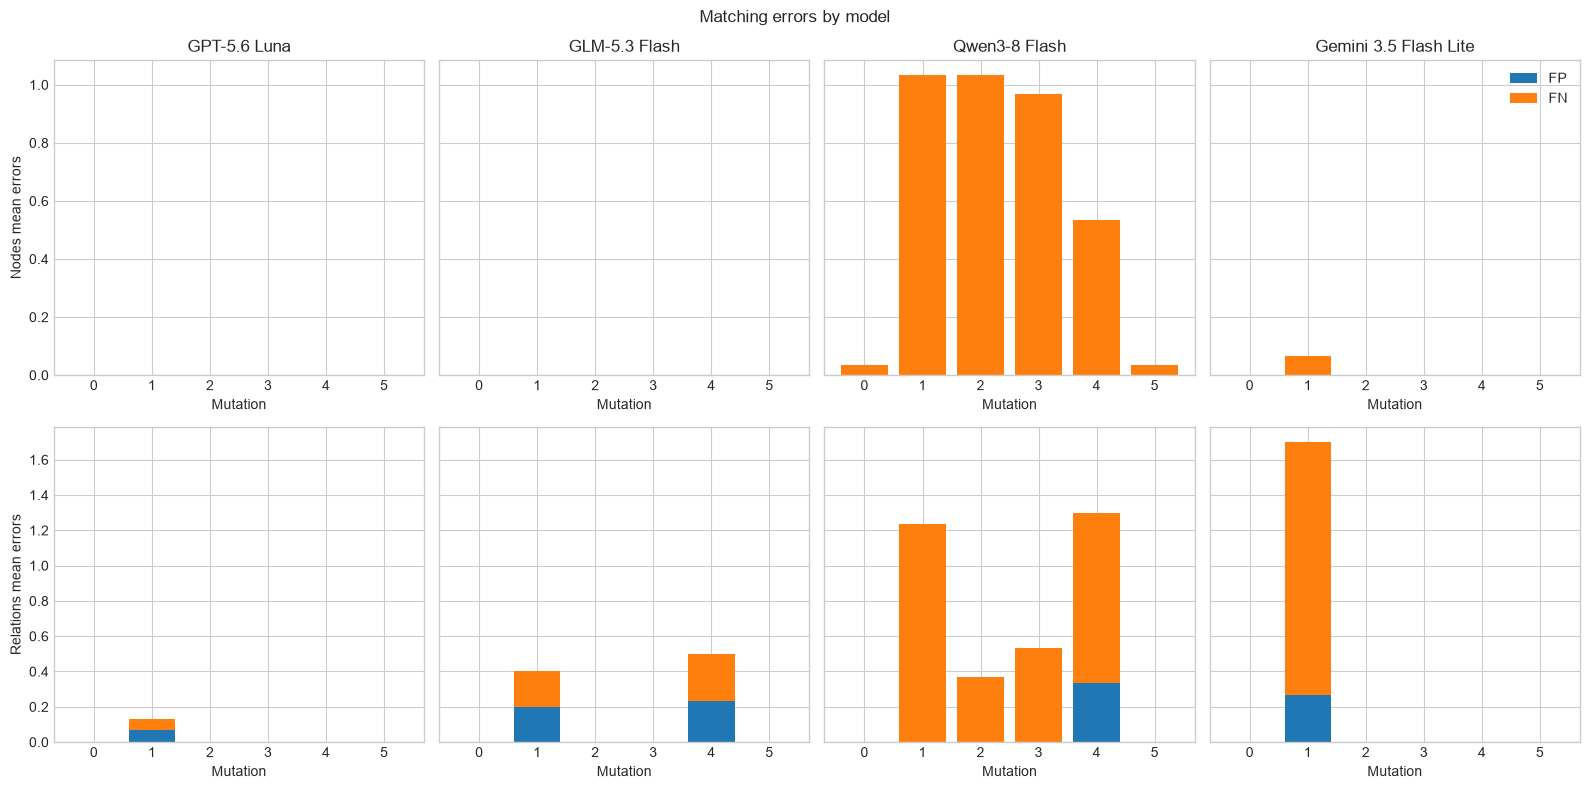

In [13]:
errors = df.groupby(["model", "mutation"], sort=False)[
    ["nodes_fp", "nodes_fn", "relations_fp", "relations_fn"]
].mean()

fig, axes = plt.subplots(
    2, len(EXPERIMENTS), figsize=(4 * len(EXPERIMENTS), 8), sharey="row"
)
for row, (component, row_title) in enumerate(
    (("nodes", "Nodes"), ("relations", "Relations"))
):
    for column, model in enumerate(EXPERIMENTS.values()):
        ax = axes[row, column]
        values = errors.loc[model]
        ax.bar(values.index, values[f"{component}_fp"], label="FP")
        ax.bar(
            values.index,
            values[f"{component}_fn"],
            bottom=values[f"{component}_fp"],
            label="FN",
        )
        ax.set(title=model if row == 0 else None, xlabel="Mutation")
    axes[row, 0].set_ylabel(f"{row_title} mean errors")
axes[0, -1].legend()
fig.suptitle("Matching errors by model")
fig.tight_layout()
plt.show()

## Problematic samples and mutations

F1 is averaged across repetitions in each model heatmap. A quality drop can then be associated with a particular diagram or mutation type.

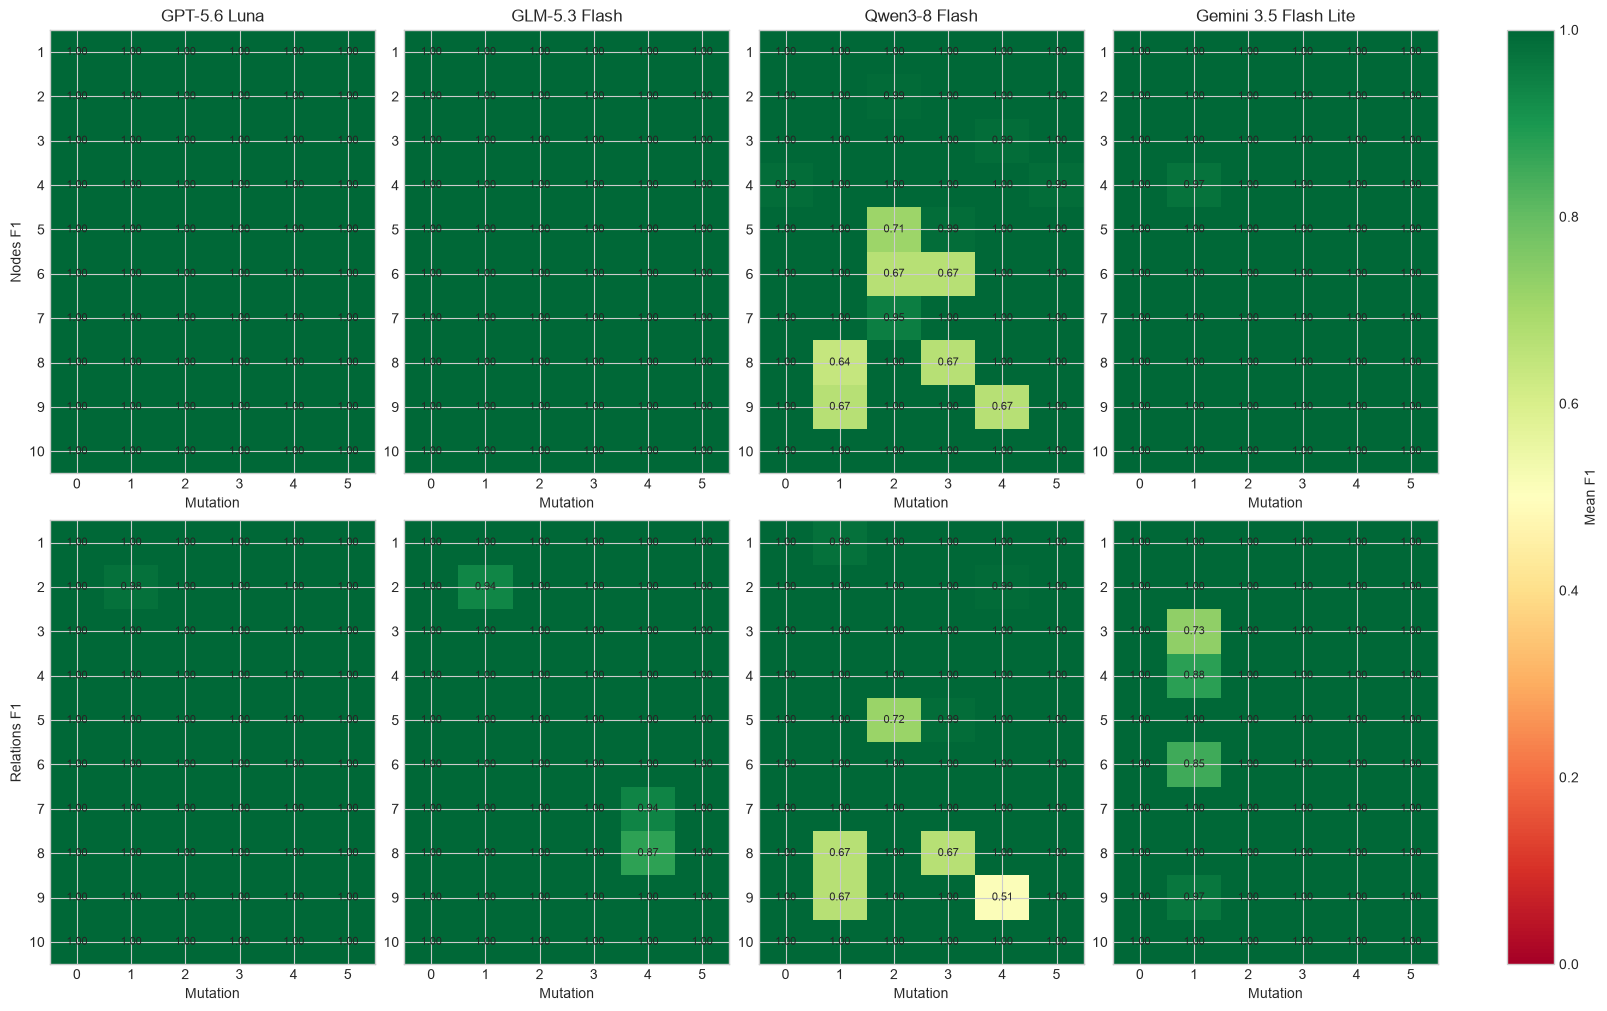

In [14]:
fig, axes = plt.subplots(
    2,
    len(EXPERIMENTS),
    figsize=(4 * len(EXPERIMENTS), 10),
    constrained_layout=True,
)
for row, (component, row_title) in enumerate(
    (("nodes", "Nodes F1"), ("relations", "Relations F1"))
):
    for column, model in enumerate(EXPERIMENTS.values()):
        ax = axes[row, column]
        matrix = df[df["model"].eq(model)].pivot_table(
            index="sample",
            columns="mutation",
            values=f"{component}_f1",
            aggfunc="mean",
        )
        image = ax.imshow(
            matrix, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto"
        )
        ax.set(
            title=model if row == 0 else None,
            xlabel="Mutation",
            ylabel=row_title if column == 0 else None,
            xticks=range(len(matrix.columns)),
            xticklabels=matrix.columns,
            yticks=range(len(matrix.index)),
            yticklabels=matrix.index,
        )
        for sample_index in range(len(matrix.index)):
            for mutation_index in range(len(matrix.columns)):
                value = matrix.iloc[sample_index, mutation_index]
                label = "n/a" if pd.isna(value) else f"{value:.2f}"
                ax.text(
                    mutation_index,
                    sample_index,
                    label,
                    ha="center",
                    va="center",
                    fontsize=8,
                )
fig.colorbar(image, ax=axes, label="Mean F1")
plt.show()